## CHECK CHECK

In [1]:
print("hello")

hello


In [2]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


## IMPORT

In [10]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset , DataLoader
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import math
import torchvision


## VERSION CHECK

In [5]:
print(torch.__version__)


2.9.1+cu126


## ADD

In [6]:
x= torch.rand(2,2)
y = torch.rand(2,2)


print(x)
print(y)


print(x+y)
torch.add(x,y)
y.add_(x)    #inplace addition
print(y)



tensor([[0.9142, 0.3295],
        [0.1808, 0.7267]])
tensor([[0.5837, 0.6212],
        [0.9770, 0.9406]])
tensor([[1.4979, 0.9508],
        [1.1578, 1.6673]])
tensor([[1.4979, 0.9508],
        [1.1578, 1.6673]])


In [7]:
z = x - y
print(z)

tensor([[-0.5837, -0.6212],
        [-0.9770, -0.9406]])


In [8]:
x = torch.rand(5,3)
print(x)
print(x[1,1].item())

tensor([[0.4558, 0.5714, 0.3646],
        [0.3929, 0.5231, 0.2592],
        [0.6241, 0.4057, 0.1889],
        [0.3359, 0.4097, 0.8167],
        [0.5268, 0.8952, 0.2645]])
0.5230945348739624


## RESIZE

In [9]:
x = torch.rand(4,4)
print(x)
y = x.view(-1,8)
print(y)

tensor([[0.9083, 0.9390, 0.9498, 0.3499],
        [0.6524, 0.3244, 0.3578, 0.4718],
        [0.6347, 0.2914, 0.5332, 0.5271],
        [0.4393, 0.0815, 0.5598, 0.2209]])
tensor([[0.9083, 0.9390, 0.9498, 0.3499, 0.6524, 0.3244, 0.3578, 0.4718],
        [0.6347, 0.2914, 0.5332, 0.5271, 0.4393, 0.0815, 0.5598, 0.2209]])


In [10]:
a = torch.ones(5)
print(a)

b= a.numpy()
print((b))
a.add_(1)
print(a)
print(b) ## both using same memory loaction so we changed a inplace but b got changed too


tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]
tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


In [11]:
a = np.ones(5)
print(a)
b = torch.from_numpy(a) 
print(b)

a += 1
print(a)
print(b)

[1. 1. 1. 1. 1.]
tensor([1., 1., 1., 1., 1.], dtype=torch.float64)
[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


## WHAT THE HELL EEZ THIS 

In [12]:
# if torch.cuda.is_available():
#     device = torch.device("cuda")          # a CUDA device object
#     x = torch.ones(5, device=device)  # directly create a tensor on GPU
#     y = torch.ones(5)                       # or just use strings ``.to("cuda")``
#     y = y.to(device)
#     z = x + y
#     print(z)
#     print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together

In [13]:
x = torch.ones(5, requires_grad=True)
print(x)

tensor([1., 1., 1., 1., 1.], requires_grad=True)


## AUTOGRAD

In [14]:
x = torch.randn(3, requires_grad=True)
print(x)


y = x + 2
print(y)
z = y*y*2
print(z)
z = z.mean()
print(z)


z.backward()  #dz/dx
print(x.grad)

tensor([ 1.8257, -1.3346,  1.7694], requires_grad=True)
tensor([3.8257, 0.6654, 3.7694], grad_fn=<AddBackward0>)
tensor([29.2719,  0.8854, 28.4165], grad_fn=<MulBackward0>)
tensor(19.5246, grad_fn=<MeanBackward0>)
tensor([5.1009, 0.8872, 5.0258])


## Prevent grad (?)

In [15]:
x = torch.randn(3, requires_grad=True)
print(x)

x.requires_grad_(False)

print(x)

y = x.detach()
print(y)
with torch.no_grad():
    y = x + 2
    print(y)

tensor([ 0.4368, -0.8250,  0.7460], requires_grad=True)
tensor([ 0.4368, -0.8250,  0.7460])
tensor([ 0.4368, -0.8250,  0.7460])
tensor([2.4368, 1.1750, 2.7460])


In [16]:
weight = torch.ones(4, requires_grad=True)

for epoch in range(2):
    model_output = (weight*3).sum()
    model_output.backward()
    print(weight.grad)
    
    weight.grad.zero_()  #resetting gradients to zero

tensor([3., 3., 3., 3.])
tensor([3., 3., 3., 3.])


## Optimizer SGD

In [17]:
weight = torch.ones(4, requires_grad=True)
optimizer = torch.optim.SGD([weight], lr=0.01)
optimizer.step()
optimizer.zero_grad()



## BACKPROPAGATION

In [18]:
x = torch.tensor(1.0)
y = torch.tensor(2.0)

w = torch.tensor(1.0 , requires_grad=True)

# forward pass 
y_hat = w * x

# compute loss
loss =( y_hat - y)**2
print(loss)

# backward pass
loss.backward()
print(w.grad)





tensor(1., grad_fn=<PowBackward0>)
tensor(-2.)


## PREDICTION GRADIENT LOSS_COMPUTE PARAMETRE UPDATE 

* manual gradient

In [19]:
x = np.array([1,2,3,4] , dtype=np.float32)
y = np.array([2,4,6,8] , dtype=np.float32)

w = 0.0

#model pred

def forward(x):
    return w*x

#loss

def loss(y,y_predicted):
    
    return ((y_predicted-y)**2).mean()


# grad

def gradient(x,y,y_predicted):
    return np.dot(2*x , y_predicted - y).mean()

print("Prediction before training: f(5) =", forward(5))


#Training 

learning_rate = 0.01
n_iters = 20
for epoch in range(n_iters):
    
    y_pred = forward(x)
    
    l = loss(y,y_pred)
    
    dw = gradient(x,y,y_pred)
    
    w -= learning_rate * dw
    
    if epoch % 1 == 0:
        print(f"epoch {epoch+1} : w = {w} , loss = {l}")
        
        
print("Prediction after training: f(5) =", forward(5))

Prediction before training: f(5) = 0.0
epoch 1 : w = 1.1999999284744263 , loss = 30.0
epoch 2 : w = 1.6799999475479126 , loss = 4.8000006675720215
epoch 3 : w = 1.871999979019165 , loss = 0.7680001854896545
epoch 4 : w = 1.948799967765808 , loss = 0.1228799968957901
epoch 5 : w = 1.9795199632644653 , loss = 0.019660834223031998
epoch 6 : w = 1.9918079376220703 , loss = 0.0031457357108592987
epoch 7 : w = 1.9967231750488281 , loss = 0.000503324146848172
epoch 8 : w = 1.9986892938613892 , loss = 8.053186320466921e-05
epoch 9 : w = 1.9994757175445557 , loss = 1.2884394891443662e-05
epoch 10 : w = 1.9997903108596802 , loss = 2.0613531432900345e-06
epoch 11 : w = 1.9999160766601562 , loss = 3.297340072094812e-07
epoch 12 : w = 1.9999663829803467 , loss = 5.282345227897167e-08
epoch 13 : w = 1.9999865293502808 , loss = 8.487816671731707e-09
epoch 14 : w = 1.9999946355819702 , loss = 1.3633503215260134e-09
epoch 15 : w = 1.999997854232788 , loss = 2.1679014139408537e-10
epoch 16 : w = 1.99999

* pytorch gradient

In [20]:
x = torch.tensor([1,2,3,4] , dtype=torch.float32)
y = torch.tensor([2,4,6,8] , dtype=torch.float32)

w = torch.tensor(0.0, dtype=torch.float32,  requires_grad=True)

#model pred

def forward(x):
    return w*x

#loss

def loss(y,y_predicted):
    
    return ((y_predicted-y)**2).mean()


# grad


print("Prediction before training: f(5) =", forward(5))


#Training 

learning_rate = 0.01
n_iters = 100
for epoch in range(n_iters):
    
    y_pred = forward(x)
    
    l = loss(y,y_pred)
    
    l.backward()
    with torch.no_grad():
        w -= learning_rate * w.grad
    
    w.grad.zero_()

    if epoch % 10 == 0:
        print(f"epoch {epoch+1} : w = {w} , loss = {l}")
        
        
print("Prediction after training: f(5) =", forward(5))

Prediction before training: f(5) = tensor(0., grad_fn=<MulBackward0>)
epoch 1 : w = 0.29999998211860657 , loss = 30.0
epoch 11 : w = 1.6653136014938354 , loss = 1.1627856492996216
epoch 21 : w = 1.934108853340149 , loss = 0.0450688973069191
epoch 31 : w = 1.987027645111084 , loss = 0.0017468547448515892
epoch 41 : w = 1.9974461793899536 , loss = 6.770494655938819e-05
epoch 51 : w = 1.9994971752166748 , loss = 2.6243997126584873e-06
epoch 61 : w = 1.9999010562896729 , loss = 1.0175587306093803e-07
epoch 71 : w = 1.9999804496765137 , loss = 3.9741685498029256e-09
epoch 81 : w = 1.999996304512024 , loss = 1.4670220593870908e-10
epoch 91 : w = 1.9999992847442627 , loss = 5.076827847005916e-12
Prediction after training: f(5) = tensor(10.0000, grad_fn=<MulBackward0>)


* LOSS COMPUTATION 

In [21]:
x = torch.tensor([1,2,3,4] , dtype=torch.float32)
y = torch.tensor([2,4,6,8] , dtype=torch.float32)

w = torch.tensor(0.0, dtype=torch.float32,  requires_grad=True)

#model pred

def forward(x):
    return w*x

#loss


# grad


print("Prediction before training: f(5) =", forward(5))


#Training 

learning_rate = 0.01
n_iters = 100
loss = nn.MSELoss()

optimizer = torch.optim.SGD([w], lr=learning_rate)
for epoch in range(n_iters):
    
    y_pred = forward(x)
    
    l = loss(y,y_pred)
    
    l.backward()
    optimizer.step()
    optimizer.zero_grad()
    

    if epoch % 10 == 0:
        print(f"epoch {epoch+1} : w = {w} , loss = {l}")
        
        
print("Prediction after training: f(5) =", forward(5))

Prediction before training: f(5) = tensor(0., grad_fn=<MulBackward0>)
epoch 1 : w = 0.29999998211860657 , loss = 30.0
epoch 11 : w = 1.6653136014938354 , loss = 1.1627856492996216
epoch 21 : w = 1.934108853340149 , loss = 0.0450688973069191
epoch 31 : w = 1.987027645111084 , loss = 0.0017468547448515892
epoch 41 : w = 1.9974461793899536 , loss = 6.770494655938819e-05
epoch 51 : w = 1.9994971752166748 , loss = 2.6243997126584873e-06
epoch 61 : w = 1.9999010562896729 , loss = 1.0175587306093803e-07
epoch 71 : w = 1.9999804496765137 , loss = 3.9741685498029256e-09
epoch 81 : w = 1.999996304512024 , loss = 1.4670220593870908e-10
epoch 91 : w = 1.9999992847442627 , loss = 5.076827847005916e-12
Prediction after training: f(5) = tensor(10.0000, grad_fn=<MulBackward0>)


* pytorch forward 

In [22]:
x = torch.tensor([[1],[2],[3],[4]] , dtype=torch.float32)
y = torch.tensor([[2],[4],[6],[8]] , dtype=torch.float32)

# w = torch.tensor(0.0, dtype=torch.float32,  requires_grad=True)

n_samples, n_features = x.shape 
print(n_samples, n_features)


X_test = torch.tensor([5], dtype=torch.float32).reshape(-1, n_features)
input_size = n_features
output_size = n_features
model = nn.Linear(input_size, output_size)
#model pred


#loss


# grad


print("Prediction before training: f(5) =", model(X_test).item())


#Training 

learning_rate = 0.01
n_iters = 200

loss = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
for epoch in range(n_iters):
    
    y_pred = model(x)
    
    l = loss(y,y_pred)
    
    l.backward()
    optimizer.step()
    optimizer.zero_grad()
    

    if epoch % 10 == 0:
        [w,b] = model.parameters()
        print(f"epoch {epoch+1} : w = {w[0][0].item()} , loss = {l}")


print("Prediction after training: f(5) =", model(X_test).item())

4 1
Prediction before training: f(5) = -2.1273438930511475
epoch 1 : w = 0.0878593772649765 , loss = 47.55690002441406
epoch 11 : w = 1.6680368185043335 , loss = 1.2316179275512695
epoch 21 : w = 1.9229272603988647 , loss = 0.033002618700265884
epoch 31 : w = 1.9646254777908325 , loss = 0.0019253564532846212
epoch 41 : w = 1.9720114469528198 , loss = 0.001058933325111866
epoch 51 : w = 1.9738579988479614 , loss = 0.0009777904488146305
epoch 61 : w = 1.9747943878173828 , loss = 0.000920371909160167
epoch 71 : w = 1.9755653142929077 , loss = 0.0008667903020977974
epoch 81 : w = 1.9762914180755615 , loss = 0.0008163384045474231
epoch 91 : w = 1.9769923686981201 , loss = 0.0007688162731938064
epoch 101 : w = 1.9776719808578491 , loss = 0.0007240667473524809
epoch 111 : w = 1.9783316850662231 , loss = 0.0006819205591455102
epoch 121 : w = 1.9789716005325317 , loss = 0.0006422335281968117
epoch 131 : w = 1.9795928001403809 , loss = 0.0006048514042049646
epoch 141 : w = 1.9801955223083496 , l

## CUSTOM LINEAR REGRESSION MODEL

In [23]:
x = torch.tensor([[1],[2],[3],[4]] , dtype=torch.float32)
y = torch.tensor([[2],[4],[6],[8]] , dtype=torch.float32)

# w = torch.tensor(0.0, dtype=torch.float32,  requires_grad=True)

n_samples, n_features = x.shape 
print(n_samples, n_features)


X_test = torch.tensor([5], dtype=torch.float32).reshape(-1, n_features)
input_size = n_features
output_size = n_features
model = nn.Linear(input_size, output_size)
#model pred


#loss


# grad


class LinearRegressionModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)
        
    def forward(self, x):
        return self.linear(x)




model = LinearRegressionModel(input_size, output_size)
print("Prediction before training: f(5) =", model(X_test).item())


#Training 

learning_rate = 0.01
n_iters = 200

loss = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
for epoch in range(n_iters):
    
    y_pred = model(x)
    
    l = loss(y,y_pred)
    
    l.backward()
    optimizer.step()
    optimizer.zero_grad()
    

    if epoch % 10 == 0:
        [w,b] = model.parameters()
        print(f"epoch {epoch+1} : w = {w[0][0].item()} , loss = {l}")


print("Prediction after training: f(5) =", model(X_test).item())

4 1
Prediction before training: f(5) = -1.5509766340255737
epoch 1 : w = 0.20223493874073029 , loss = 43.682334899902344
epoch 11 : w = 1.715665340423584 , loss = 1.1302134990692139
epoch 21 : w = 1.958956241607666 , loss = 0.029285915195941925
epoch 31 : w = 1.9979506731033325 , loss = 0.0007997636566869915
epoch 41 : w = 2.0040884017944336 , loss = 6.0309877881081775e-05
epoch 51 : w = 2.0049450397491455 , loss = 3.8869773561600596e-05
epoch 61 : w = 2.0049562454223633 , loss = 3.6142897442914546e-05
epoch 71 : w = 2.004835367202759 , loss = 3.402767833904363e-05
epoch 81 : w = 2.0046963691711426 , loss = 3.204729000572115e-05
epoch 91 : w = 2.004558563232422 , loss = 3.0181363399606198e-05
epoch 101 : w = 2.0044238567352295 , loss = 2.842368121491745e-05
epoch 111 : w = 2.004293441772461 , loss = 2.6769794203573838e-05
epoch 121 : w = 2.004166603088379 , loss = 2.5211516913259402e-05
epoch 131 : w = 2.0040435791015625 , loss = 2.3745478756609373e-05
epoch 141 : w = 2.003924131393432

## APPLY ALL 

epoch: 10, loss = 4482.1548
epoch: 20, loss = 3339.9309
epoch: 30, loss = 2514.1797
epoch: 40, loss = 1916.5431
epoch: 50, loss = 1483.5511
epoch: 60, loss = 1169.5406
epoch: 70, loss = 941.6132
epoch: 80, loss = 776.0329
epoch: 90, loss = 655.6543
epoch: 100, loss = 568.0754


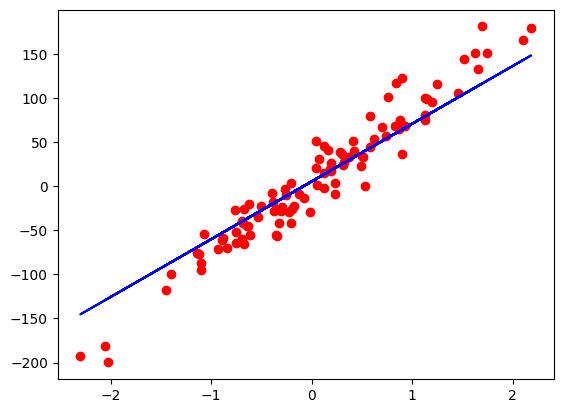

In [24]:
X_numpy , y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

y = y.view(y.shape[0],1)
n_samples , n_features = X.shape
input_size = n_features
output_size = 1
model = nn.Linear(input_size, output_size)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)



num_epochs = 100
for epoch in range(num_epochs):
    # forward pass and loss
    y_predicted = model(X)
    loss = criterion(y_predicted, y)
    
    # backward pass
    loss.backward()
    
    # update
    optimizer.step()
    
    # zero gradients
    optimizer.zero_grad()
    
    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')
 
 
# plot

predicted = model(X).detach().numpy()
plt.plot(X_numpy, y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()
        

## LOGISTIC REGRESSION

* prepare data
* model
* loss and optimizer
* training loop

In [25]:
bc = datasets.load_breast_cancer()
X, y = bc.data , bc.target
n_samples, n_features = X.shape

# print(n_samples, n_features)

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32)).view(y_train.shape[0],1)
y_test = torch.from_numpy(y_test.astype(np.float32)).view(y_test.shape[0],1)



#model steup
class LogisticRegression(nn.Module):
    def __init__(self, n_input_features):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(n_input_features,1) 
        
    def forward(self,x):
        y_predicted = torch.sigmoid(self.linear(x))
        return y_predicted
    
model = LogisticRegression(n_features)


#loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


#training

num_epochs = 100

for epoch in range( num_epochs):
    y_predicted = model(X_train)
    loss = criterion(y_predicted , y_train)
    
    loss.backward()
    
    optimizer.step()
    
    optimizer.zero_grad()
    
    
    
    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')
        
with torch.no_grad():
    y_predicted = model(X_test)
    y_predicted_cls = y_predicted.round()
    acc = y_predicted_cls.eq(y_test).sum() / float(y_test.shape[0])
    print(f'accuracy = {acc:.4f}')


epoch: 10, loss = 0.6965
epoch: 20, loss = 0.5323
epoch: 30, loss = 0.4394
epoch: 40, loss = 0.3808
epoch: 50, loss = 0.3403
epoch: 60, loss = 0.3105
epoch: 70, loss = 0.2875
epoch: 80, loss = 0.2691
epoch: 90, loss = 0.2539
epoch: 100, loss = 0.2411
accuracy = 0.9123


## DATASET AND DATALOADER 

In [ ]:
class Winedataset(Dataset):
    def __init__(self):
        # data load
        xy = np.loadtxt('/home/nidhi/BUET /LABS/BUET-ACADEMICS/3-2 Sessionals/CSE 330/pytorch practice/wine.csv', delimiter="," , dtype=np.float32 , skiprows=1)
        self.x = torch.from_numpy(xy[:, 1:])
        self.y = torch.from_numpy(xy[:,[0]])
        self.n_samples = xy.shape[0]
        
        

    def __len__(self):
        return self.n_samples

    def __getitem__(self, index):
        # dataset[0]
        return self.x[index], self.y[index] #tuple return
        
        
dataset = Winedataset()

# first_data = dataset[0]
# features , labels = first_data
# print(features, labels)


dataloader = DataLoader(dataset= dataset , batch_size = 4 , shuffle = True , num_workers = 2)

dataiter = iter(dataloader)
data = next(dataiter)

features , labels = data
print(features , labels)



num_epochs = 2
total_samples = len(dataset)
n_iterations = math.ceil(total_samples/4)

print(total_samples , n_iterations)

for epoch in range(num_epochs):
    for i , (inputs , labels) in enumerate(dataloader):
        if (i+1) % 5 == 0:  
            print(f'epoch {epoch+1} / {num_epochs} , step {i+1} / {n_iterations} inputs {inputs.shape} ') 
            
            


tensor([[1.3730e+01, 1.5000e+00, 2.7000e+00, 2.2500e+01, 1.0100e+02, 3.0000e+00,
         3.2500e+00, 2.9000e-01, 2.3800e+00, 5.7000e+00, 1.1900e+00, 2.7100e+00,
         1.2850e+03],
        [1.2530e+01, 5.5100e+00, 2.6400e+00, 2.5000e+01, 9.6000e+01, 1.7900e+00,
         6.0000e-01, 6.3000e-01, 1.1000e+00, 5.0000e+00, 8.2000e-01, 1.6900e+00,
         5.1500e+02],
        [1.2510e+01, 1.2400e+00, 2.2500e+00, 1.7500e+01, 8.5000e+01, 2.0000e+00,
         5.8000e-01, 6.0000e-01, 1.2500e+00, 5.4500e+00, 7.5000e-01, 1.5100e+00,
         6.5000e+02],
        [1.4300e+01, 1.9200e+00, 2.7200e+00, 2.0000e+01, 1.2000e+02, 2.8000e+00,
         3.1400e+00, 3.3000e-01, 1.9700e+00, 6.2000e+00, 1.0700e+00, 2.6500e+00,
         1.2800e+03]]) tensor([[1.],
        [3.],
        [3.],
        [1.]])
178 45
epoch 1 / 2 , step 5 / 45 inputs torch.Size([4, 13]) 
epoch 1 / 2 , step 10 / 45 inputs torch.Size([4, 13]) 
epoch 1 / 2 , step 15 / 45 inputs torch.Size([4, 13]) 
epoch 1 / 2 , step 20 / 45 inputs t

In [41]:
class Winedataset(Dataset):
    def __init__(self , transform=None):
        # data load
        xy = np.loadtxt('/home/nidhi/BUET /LABS/BUET-ACADEMICS/3-2 Sessionals/CSE 330/pytorch practice/wine.csv', delimiter="," , dtype=np.float32 , skiprows=1)
        self.x = xy[:, 1:]
        self.y = xy[:,[0]]
        self.n_samples = xy.shape[0]

        self.transform = transform

    def __len__(self):
        return self.n_samples

    def __getitem__(self, index):
        # dataset[0]
        sample =  self.x[index], self.y[index] #tuple return

        if self.transform:
            sample = self.transform(sample)

        return sample





class ToTensor:
    def __call__(self, sample):
        inputs , targets = sample
        return torch.from_numpy(inputs) , torch.from_numpy(targets)




class MulTransform:
    def __init__(self, factor):
        self.factor = factor 
        
    def __call__(self , samples):
        inputs ,targets = samples 
        
        inputs *= self.factor 

        return inputs , targets



dataset = Winedataset(transform = ToTensor())


first_data = dataset[0]

n_features , n_labesl = first_data

print(type(n_features) , type(n_labesl))




composed = torchvision.transforms.Compose([ToTensor(), MulTransform(4)])

dataset = Winedataset(transform=composed)




first_data = dataset[0]

n_features , n_labesl = first_data
print(n_features,n_labesl)
print(type(n_features) , type(n_labesl))
# first_data = dataset[0]
# features , labels = first_data
# print(features, labels)


# dataloader = DataLoader(dataset= dataset , batch_size = 4 , shuffle = True , num_workers = 2)

# dataiter = iter(dataloader)
# data = next(dataiter)

# features , labels = data
# print(features , labels)



# num_epochs = 2
# total_samples = len(dataset)
# n_iterations = math.ceil(total_samples/4)

# print(total_samples , n_iterations)

# for epoch in range(num_epochs):
#     for i , (inputs , labels) in enumerate(dataloader):
#         if (i+1) % 5 == 0:  
#             print(f'epoch {epoch+1} / {num_epochs} , step {i+1} / {n_iterations} inputs {inputs.shape} ') 
            
            


<class 'torch.Tensor'> <class 'torch.Tensor'>
tensor([5.6920e+01, 6.8400e+00, 9.7200e+00, 6.2400e+01, 5.0800e+02, 1.1200e+01,
        1.2240e+01, 1.1200e+00, 9.1600e+00, 2.2560e+01, 4.1600e+00, 1.5680e+01,
        4.2600e+03]) tensor([1.])
<class 'torch.Tensor'> <class 'torch.Tensor'>


## SOTMAX AND CROSS-ENTROPY

In [42]:
def softmax(x):
    return np.exp(x)/np.sum(np.exp(x),axis = 0)


x = np.array([2.0,1.0,0.1])

outputs = softmax(x)
print('softmax numpy : ', outputs)

softmax numpy :  [0.65900114 0.24243297 0.09856589]


In [43]:
x = torch.tensor([2.0,1.0,0.1])


outputs = torch.softmax(x, dim=0)   
print(outputs)

tensor([0.6590, 0.2424, 0.0986])


In [44]:
def cross_entropy(actual , predicted):
    loss = -np.sum(actual * np.log(predicted))
    return loss
y = np.array([1,0,0])


y_pred_good = np.array([0.9,0.05,0.05])
y_pred_bad = np.array([0.4,0.3,0.3])
l1 = cross_entropy(y , y_pred_good)
l2 = cross_entropy(y , y_pred_bad)
print(f'Loss good : {l1} , Loss bad : {l2}')


Loss good : 0.10536051565782628 , Loss bad : 0.916290731874155


In [51]:
loss = nn.CrossEntropyLoss()



Y = torch.tensor([0])

# nsamples * nclasses
Y_pred_good = torch.tensor([[2.0,1.0,0.1]])

Y_pred_bad = torch.tensor([[0.5,2.0,0.3]])


l1 = loss(Y_pred_good , Y)

l2 = loss(Y_pred_bad , Y)


print(f'Loss good : {l1.item()} , Loss bad : {l2.item()}')


_, predictions1 = torch.max(Y_pred_good , 1)
_, predictions2 = torch.max(Y_pred_bad , 1)
print(f'Predictions : {predictions1}')
print(f'Predictions : {predictions2}')

Loss good : 0.4170299470424652 , Loss bad : 1.840616226196289
Predictions : tensor([0])
Predictions : tensor([1])


In [52]:
loss = nn.CrossEntropyLoss()



Y = torch.tensor([2,0,1])

# nsamples * nclasses
Y_pred_good = torch.tensor([[0.1,1.0,2.1],[2.0,1.0,0.1],[0.1,3.0,0.1]])

Y_pred_bad = torch.tensor([[2.1,1.0,0.1],[0.1,1.0,2.1],[0.1,3.0,0.1]])


l1 = loss(Y_pred_good , Y)

l2 = loss(Y_pred_bad , Y)


print(f'Loss good : {l1.item()} , Loss bad : {l2.item()}')


_, predictions1 = torch.max(Y_pred_good , 1)
_, predictions2 = torch.max(Y_pred_bad , 1)
print(f'Predictions : {predictions1}')
print(f'Predictions : {predictions2}')

Loss good : 0.3018244206905365 , Loss bad : 1.6241613626480103
Predictions : tensor([2, 0, 1])
Predictions : tensor([0, 2, 1])


In [ ]:
class NeuralNet2(nn.Module):
    def __init__ (self , input_size , hidden_size , num_classes ):
        super(NeuralNet2 , self ).__init__()
        self.Linear1 = nn.Linear(input_size , hidden_size)
        
        self.relu = nn.ReLU()
        self.Linear2 = nn.Linear(hidden_size , num_classes)
        
        
        

    def forward(self , x):
        out = self.Linear1(x)
        out = self.relu(out)
        out = self.Linear2(out)
        
        return out 
    
    
model = NeuralNet2(input_size=28*28 , hidden_size=5 , num_classes=3)
criterion = nn.CrossEntropyLoss()

## ACTIVATION FUNCTIONS

In [ ]:

class NeuralNet(nn.Module):
    def __init__ (self , input_size , hidden_size , num_classes ):
        super(NeuralNet , self ).__init__()
        self.Linear1 = nn.Linear(input_size , hidden_size)
        
        self.relu = nn.ReLU()
        self.Linear2 = nn.Linear(hidden_size , num_classes)
        self.sigmoid = nn.Sigmoid()
        
        
        
        

    def forward(self , x):
        out = self.Linear1(x)
        out = self.relu(out)
        out = self.Linear2(out)
        out = self.sigmoid(out)
        return out 
    
    
model = NeuralNet2(input_size=28*28 , hidden_size=5 , num_classes=3)
criterion = nn.CrossEntropyLoss()



In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


input_size = 784
hidden_size = 100
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=torchvision.transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)



examples = iter(train_loader)
samples , labels = next(examples)
print(samples.shape , labels.shape)






torch.Size([100, 1, 28, 28]) torch.Size([100])


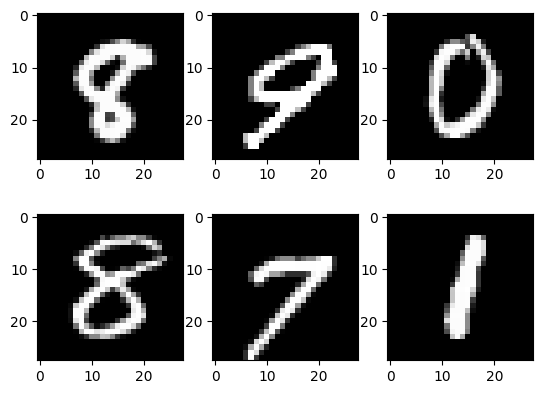

In [4]:
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(samples[i][0] , cmap = 'gray')
plt.show()

## FEEDFORWARD 

In [ ]:
class NeuralNet(nn.Module):

    def __init__(self, input_size ,hidden_size , num_classes):
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        x = self.l1(x)
        x = self.relu(x)
        x = self.l2(x)
        return x
    
    
model = NeuralNet(input_size, hidden_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


n_total_steps = len(train_loader)
#train
for epoch in range(num_epochs):
    for i , (images, labels) in enumerate(train_loader):
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        #forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        #backward
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        
        if (i+1) % 100 == 0:
            print (f'epoch {epoch+1} / {num_epochs} , step {i+1} / {n_total_steps} , loss = {loss.item():.4f}')
#test


with torch.no_grad():
    n_correct = 0 
    n_samples = 0 
    
    
    for images , labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        
        _, predicted = torch.max(outputs, 1)
        
        n_samples += labels.shape[0]
        
        n_correct += (predicted == labels).sum().item()
        
        
    acc = 100.0 * n_correct / n_samples
    print(f'accuracy = {acc} ')
        

epoch 1 / 2 , step 100 / 600 , loss = 0.4903
epoch 1 / 2 , step 200 / 600 , loss = 0.2879
epoch 1 / 2 , step 300 / 600 , loss = 0.3113
epoch 1 / 2 , step 400 / 600 , loss = 0.3165
epoch 1 / 2 , step 500 / 600 , loss = 0.2129
epoch 1 / 2 , step 600 / 600 , loss = 0.3059
epoch 2 / 2 , step 100 / 600 , loss = 0.3500
epoch 2 / 2 , step 200 / 600 , loss = 0.3278
epoch 2 / 2 , step 300 / 600 , loss = 0.1506
epoch 2 / 2 , step 400 / 600 , loss = 0.1574
epoch 2 / 2 , step 500 / 600 , loss = 0.3566
epoch 2 / 2 , step 600 / 600 , loss = 0.2885
accuracy = 95.25 


## CONVOLUTIONAL NEURAL NETWORK CNN

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


input_size = 784
hidden_size = 100
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001


train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=torchvision.transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6 ,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        
        
        self.fc1 = nn.Linear(16*5*5 , 120)
        self.fc2 = nn.Linear(120 , 84)
        self.fc3 = nn.Linear(84 , 10)
        
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 + relu + pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 + relu + pool
        
        x = x.view(x.size(0), -1)             # flatten safely
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# class CNN_MNIST(nn.Module):
#     def __init__(self):
#         super().__init__()
        
#         self.conv1 = nn.Conv2d(1, 6, 5)
#         self.pool  = nn.MaxPool2d(2,2)
#         self.conv2 = nn.Conv2d(6, 16, 5)
        
#         self.fc1 = nn.Linear(16*4*4, 120)
#         self.fc2 = nn.Linear(120, 84)
#         self.fc3 = nn.Linear(84, 10)


   
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


n_total_steps = len(train_loader)
#train
for epoch in range(20):
    for i , (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        #forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        #backward
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        
        if (i+1) % 100 == 0:
            print (f'epoch {epoch+1} / {num_epochs} , step {i+1} / {n_total_steps} , loss = {loss.item():.4f}')
#test


with torch.no_grad():
    n_correct = 0 
    n_samples = 0 
    
    
    for images , labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        
        
        _, predicted = torch.max(outputs, 1)
        
        n_samples += labels.shape[0]
        
        n_correct += (predicted == labels).sum().item()
        
        
    acc = 100.0 * n_correct / n_samples
    print(f'accuracy = {acc} ')
        

epoch 1 / 2 , step 100 / 500 , loss = 1.9314
epoch 1 / 2 , step 200 / 500 , loss = 1.7752
epoch 1 / 2 , step 300 / 500 , loss = 1.6555
epoch 1 / 2 , step 400 / 500 , loss = 1.4795
epoch 1 / 2 , step 500 / 500 , loss = 1.5770
epoch 2 / 2 , step 100 / 500 , loss = 1.7949
epoch 2 / 2 , step 200 / 500 , loss = 1.3992
epoch 2 / 2 , step 300 / 500 , loss = 1.4641
epoch 2 / 2 , step 400 / 500 , loss = 1.4839
epoch 2 / 2 , step 500 / 500 , loss = 1.5806
epoch 3 / 2 , step 100 / 500 , loss = 1.4021
epoch 3 / 2 , step 200 / 500 , loss = 1.3875
epoch 3 / 2 , step 300 / 500 , loss = 1.1587
epoch 3 / 2 , step 400 / 500 , loss = 1.5301
epoch 3 / 2 , step 500 / 500 , loss = 1.4443
epoch 4 / 2 , step 100 / 500 , loss = 1.3933
epoch 4 / 2 , step 200 / 500 , loss = 1.5346
epoch 4 / 2 , step 300 / 500 , loss = 1.4520
epoch 4 / 2 , step 400 / 500 , loss = 1.3192
epoch 4 / 2 , step 500 / 500 , loss = 1.3584
epoch 5 / 2 , step 100 / 500 , loss = 1.3165
epoch 5 / 2 , step 200 / 500 , loss = 1.2433
epoch 5 / 